# belief eye neural analysis


## imports

In [1]:
%reload_ext autoreload
%autoreload 2
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
# misc
import pickle
from collections import defaultdict
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

# load data

## load standard data


In [2]:
df = pd.read_pickle(resdir/'0417_m51df.pkl')
len(df)
df=df[df.session==41]

In [3]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [4]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [5]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [6]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timedf=pd.DataFrame({'timer':timer})
timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())


timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

In [7]:
timedf.columns                                                           

Index(['timer', 'rawcov', 'belief', 'state', 'eye', 'timeratio', 'mv', 'mw',
       'belief_heading', 'countdown', 'belief_angle_from_start', 'PPC',
       'uncertainty', 'density', 'fullon', 'error', 'dbelief', 'deye',
       'dneural'],
      dtype='object')

## load iti data

In [8]:
itidf = pd.read_pickle(resdir/'0421iti_m51df.pkl')
len(itidf)
itidf=itidf[itidf.session==41]
itidf['time_ratio']=itidf.apply(lambda x: x.timer/x.timer[-1], axis=1)

In [9]:
for session in sorted(itidf.session.unique())[:1]:
    sessitidf=itidf[(itidf.session==session)]

# state=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessitidf.ff_hori.to_numpy())
eye=np.concatenate(sessitidf.eye_hori.to_numpy())
timeratio=np.concatenate(sessitidf.time_ratio.to_numpy())
timer=np.concatenate(sessitidf.timer.to_numpy())
countdown=np.concatenate(sessitidf.countdown.to_numpy())

# make a itidf by time (each row is a time, instead of a trial)
sessitidf['density_t']=sessitidf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['fullon_t']=sessitidf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['error_t']=sessitidf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timeitidf=pd.DataFrame({'timer':timer})
# timeitidf['rawcov']=list(np.vstack(sessitidf['rawcov'].to_numpy()))
# timeitidf['belief']=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
timeitidf['state']=np.concatenate(sessitidf.ff_hori.to_numpy())
timeitidf['eye']=np.concatenate(sessitidf.eye_hori.to_numpy())
timeitidf['timeratio']=np.concatenate(sessitidf.time_ratio.to_numpy())
timeitidf['mv']=np.concatenate(sessitidf.mv.to_numpy())
timeitidf['mw']=np.concatenate(sessitidf.mw.to_numpy())
# timeitidf['belief_heading']=np.concatenate(sessitidf.belief_heading.to_numpy())
timeitidf['timer']=np.concatenate(sessitidf.timer.to_numpy())
timeitidf['countdown']=np.concatenate(sessitidf.countdown.to_numpy())
# timeitidf['belief_angle_from_start']=np.concatenate(sessitidf.belief_angle_from_start.to_numpy())
timeitidf['PPC']=list(np.vstack(sessitidf.PPC.to_numpy()))

# timeitidf['uncertainty']=list(np.concatenate(sessitidf.relcov.to_numpy()))

timeitidf['density']=np.concatenate(sessitidf.density_t.to_numpy())
timeitidf['fullon']=np.concatenate(sessitidf.fullon_t.to_numpy())
timeitidf['error']=np.concatenate(sessitidf.error_t.to_numpy())


# timeitidf['dbelief']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['deye']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['dneural']=list(np.vstack(sessitidf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timeitidf.head()
# timeitidf = timeitidf.dropna(subset=['eye', 'state'])

,timer,state,eye,timeratio,mv,mw,countdown,PPC,density,fullon,error,deye,dneural
0,0,-0.411339,28.940651,0.000000,-0.003190,-0.001378,-37,"[0.106192164, 0.19640955, 0.0, 0.0, 0.05650172...",0.005,0,174.501175,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,1,-0.470667,28.920336,0.027027,0.023303,0.007235,-36,"[0.10775572, 0.1846899, 0.0, 3.3458742e-05, 0....",0.005,0,174.501175,-0.020315,"[0.0015635565, -0.011719659, 0.0, 3.3458742e-0..."
2,2,-0.533338,28.902283,0.054054,-0.004524,-0.002155,-35,"[0.109807715, 0.16330647, 0.0, 8.815204e-05, 0...",0.005,0,174.501175,-0.018053,"[0.0020519942, -0.02138342, 0.0, 5.4693297e-05..."
3,3,-0.500699,28.880598,0.081081,-0.015537,-0.000820,-34,"[0.110675946, 0.13578184, 0.0, 0.0002181784, 0...",0.005,0,174.501175,-0.021685,"[0.00086823106, -0.027524635, 0.0, 0.000130026..."
4,4,-0.481149,28.881540,0.108108,0.015418,0.008251,-33,"[0.10878229, 0.10615871, 0.0, 0.00050727994, 0...",0.005,0,174.501175,0.000942,"[-0.0018936545, -0.029623128, 0.0, 0.000289101..."


# plots


--- Full Neural Encoding Analysis with Heatmaps ---
Neural data shape: (400117, 112)
Belief data shape: (400117,)
Eye data shape: (400117,)
Analyzing 112 neurons

Neuron categorization summary:
  Not significant: 65 neurons (58.0%)
  Indep. belief dominant: 19 neurons (17.0%)
  Indep. eye dominant: 19 neurons (17.0%)
  Both indep. significant: 9 neurons (8.0%)

Independent Belief: Selected 10 neurons
  Neuron indices: [ 68 101 105 110  59   0  91  82  22  33]...


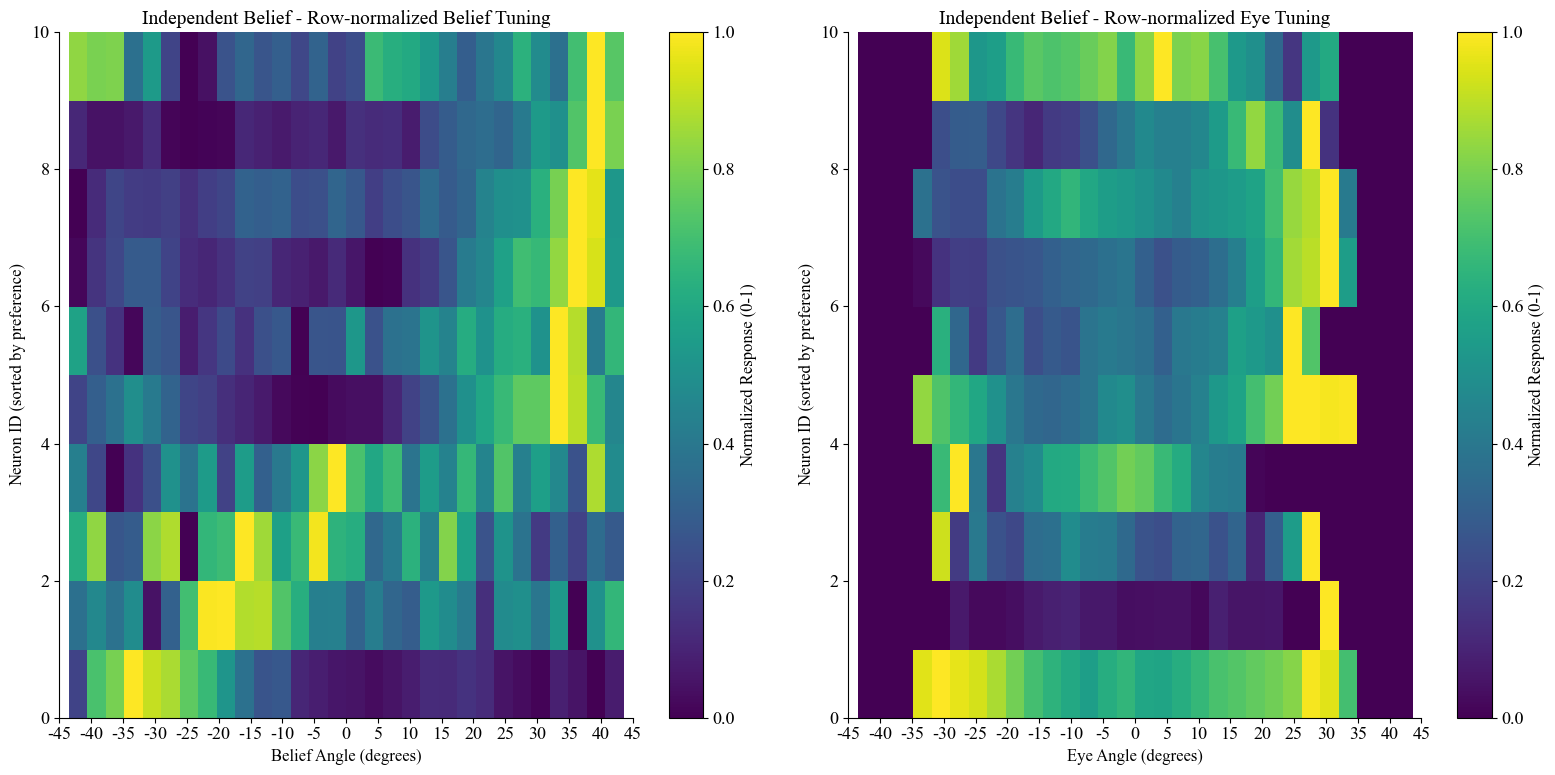


Independent Belief Example Neurons Statistics:
  Neuron 68:
    Independent belief coef: -40.039
    Independent eye coef: 3.871
    Total belief coef: -45.117
    Total eye coef: -3.387

  Neuron 101:
    Independent belief coef: 35.501
    Independent eye coef: 1.630
    Total belief coef: 50.006
    Total eye coef: 9.677

  Neuron 105:
    Independent belief coef: 24.856
    Independent eye coef: -1.845
    Total belief coef: 29.112
    Total eye coef: 2.839

  Neuron 110:
    Independent belief coef: -22.622
    Independent eye coef: 0.167
    Total belief coef: -29.482
    Total eye coef: -4.576

  Neuron 59:
    Independent belief coef: -21.863
    Independent eye coef: 0.348
    Total belief coef: -28.124
    Total eye coef: -4.177


Independent Eye: Selected 10 neurons
  Neuron indices: [ 21 103  24  38  52  97  41  10 104  93]...


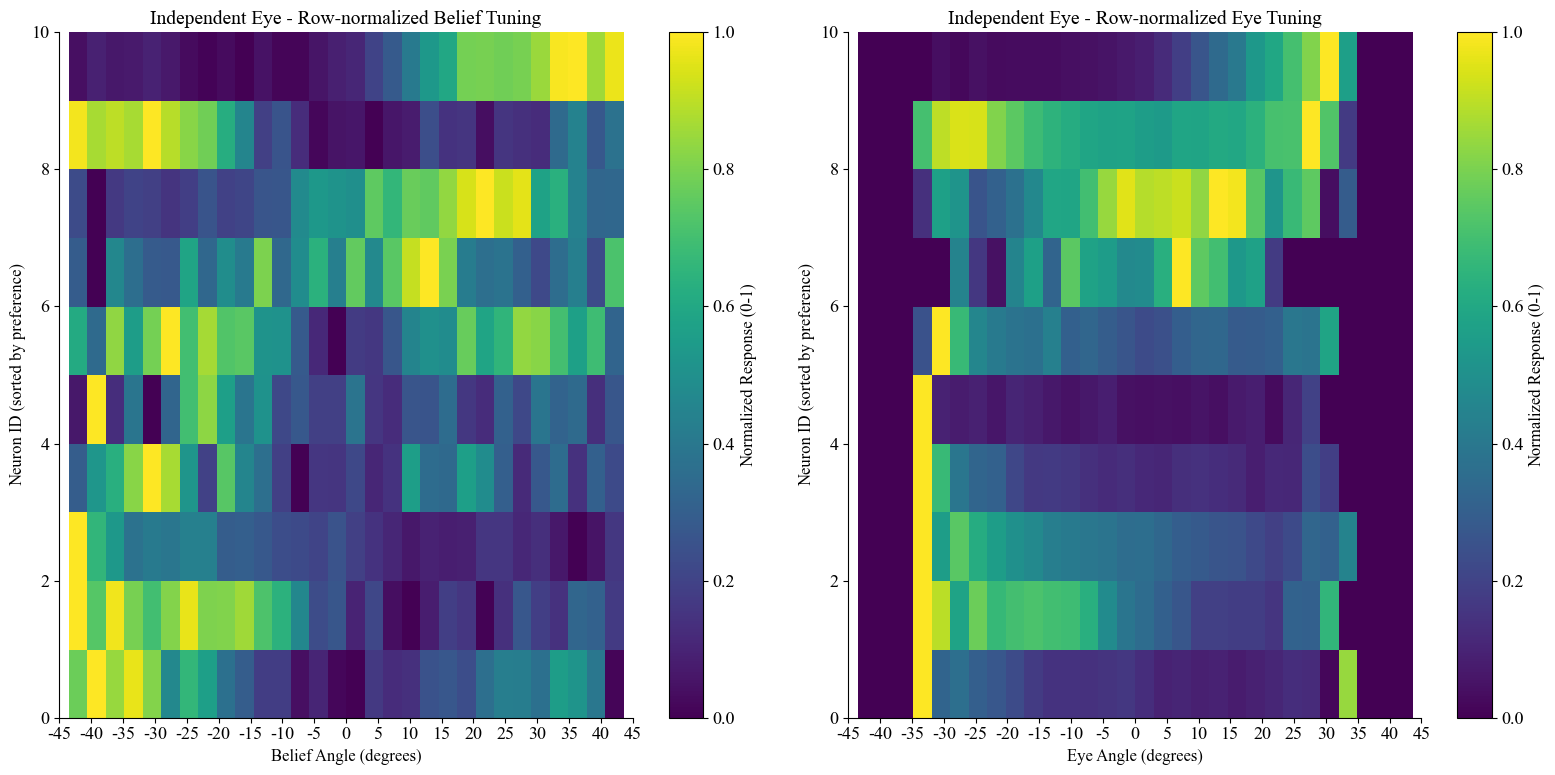


Independent Eye Example Neurons Statistics:
  Neuron 21:
    Independent belief coef: 0.602
    Independent eye coef: 27.021
    Total belief coef: 54.183
    Total eye coef: 35.743

  Neuron 103:
    Independent belief coef: 4.405
    Independent eye coef: -14.802
    Total belief coef: -23.442
    Total eye coef: -18.576

  Neuron 24:
    Independent belief coef: -6.575
    Independent eye coef: -13.035
    Total belief coef: -34.416
    Total eye coef: -18.572

  Neuron 38:
    Independent belief coef: 0.256
    Independent eye coef: -11.439
    Total belief coef: -22.262
    Total eye coef: -15.022

  Neuron 52:
    Independent belief coef: 2.679
    Independent eye coef: 9.902
    Total belief coef: 23.095
    Total eye coef: 13.619

No neurons found for Both Independent

All Neurons: Selected 112 neurons
  Neuron indices: [0 1 2 3 4 5 6 7 8 9]...


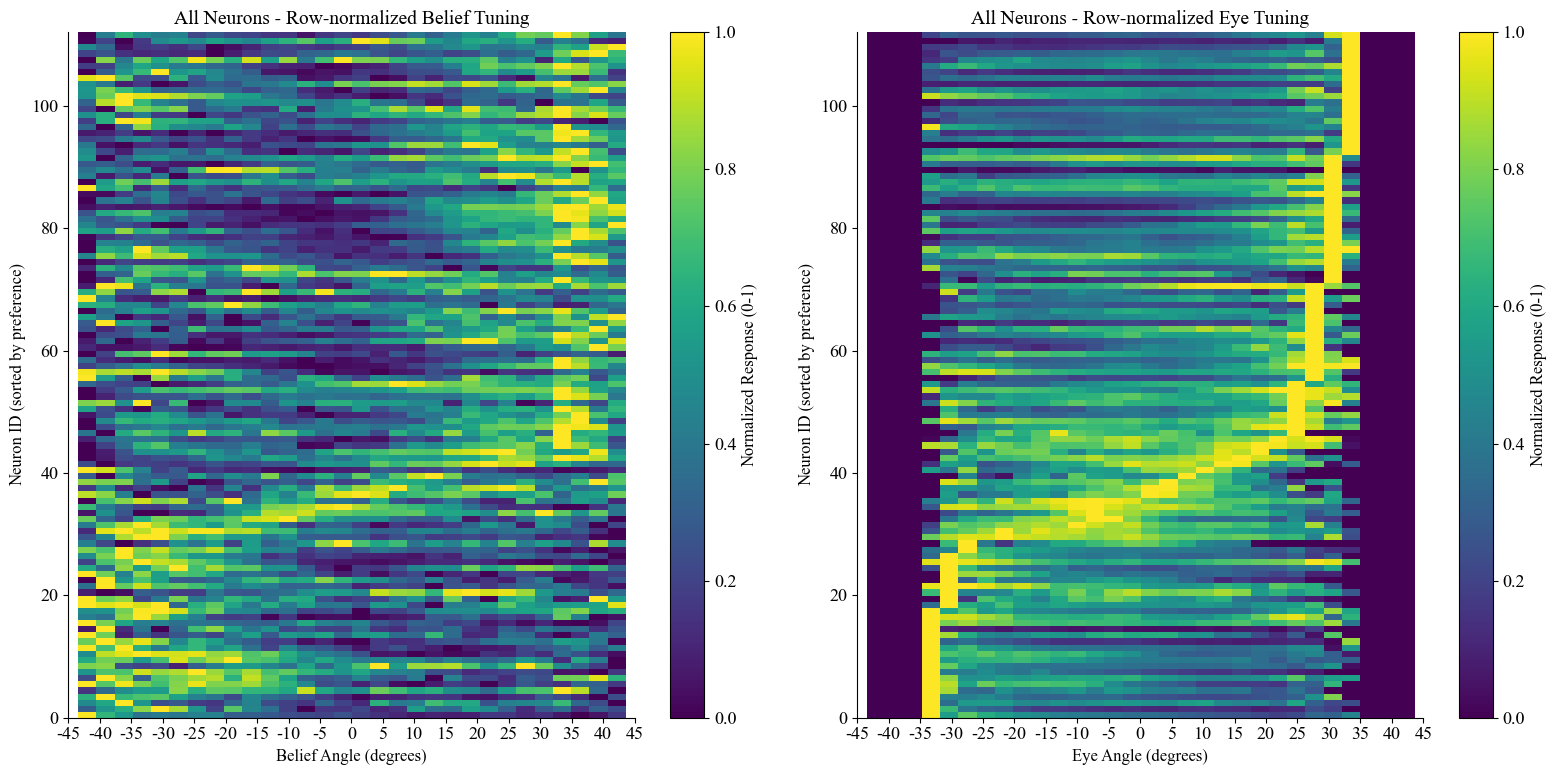

In [45]:
def analyze_and_visualize_neuron_encoding(timedf, n_bins=30, n_examples=10):
    """
    Perform full encoding analysis and create heatmaps for example neurons from each category.
    Normalizes each row (neuron) separately in the heatmaps.
    Consistent sorting across both plots in each figure.
    Includes an additional plot for all neurons.
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_bins : int
        Number of bins for degree ranges
    n_examples : int
        Number of neurons to show per category
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import LinearRegression
    
    print("\n--- Full Neural Encoding Analysis with Heatmaps ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy()
    
    print(f"Neural data shape: {neural_data.shape}")
    print(f"Belief data shape: {belief_data.shape}")
    print(f"Eye data shape: {eye_data.shape}")
    
    # Ensure eye_data is 2D for sklearn
    if len(eye_data.shape) == 1:
        eye_data_2d = eye_data.reshape(-1, 1)
    else:
        eye_data_2d = eye_data
    
    # Get number of neurons
    n_neurons = neural_data.shape[1]
    print(f"Analyzing {n_neurons} neurons")
    
    # Step 1: Calculate coefficients for each neuron
    
    # Calculate total belief coefficients
    model_total_belief = LinearRegression().fit(neural_data, belief_data)
    total_belief_coefs = model_total_belief.coef_
    
    # Calculate total eye coefficients
    model_total_eye = LinearRegression().fit(neural_data, eye_data_2d)
    total_eye_coefs = model_total_eye.coef_[0]  # Flatten
    
    # Calculate independent belief coefficients
    model_eye = LinearRegression().fit(eye_data_2d, neural_data)
    neural_residuals_after_eye = neural_data - model_eye.predict(eye_data_2d)
    
    model_indep_belief = LinearRegression().fit(neural_residuals_after_eye, belief_data)
    indep_belief_coefs = model_indep_belief.coef_
    
    # Calculate independent eye coefficients
    model_belief = LinearRegression().fit(belief_data.reshape(-1, 1), neural_data)
    neural_residuals_after_belief = neural_data - model_belief.predict(belief_data.reshape(-1, 1))
    
    model_indep_eye = LinearRegression().fit(neural_residuals_after_belief, eye_data_2d)
    indep_eye_coefs = model_indep_eye.coef_[0]  # Flatten
    
    # Step 2: Create neuron DataFrame for categorization
    neuron_df = pd.DataFrame({
        'neuron_idx': np.arange(n_neurons),
        'total_belief_coef': total_belief_coefs,
        'total_eye_coef': total_eye_coefs,
        'indep_belief_coef': indep_belief_coefs,
        'indep_eye_coef': indep_eye_coefs,
        'total_belief_abs': np.abs(total_belief_coefs),
        'total_eye_abs': np.abs(total_eye_coefs),
        'indep_belief_abs': np.abs(indep_belief_coefs),
        'indep_eye_abs': np.abs(indep_eye_coefs)
    })
    
    # Step 3: Define thresholds and categorize neurons
    threshold_pct = 75  # Use top 25% as threshold
    threshold_indep_belief = np.percentile(neuron_df['indep_belief_abs'], threshold_pct)
    threshold_indep_eye = np.percentile(neuron_df['indep_eye_abs'], threshold_pct)
    
    # Create categorizations
    neuron_df['indep_category'] = 'Not significant'
    
    # Independent belief dominant
    indep_belief_dominant_mask = (neuron_df['indep_belief_abs'] >= threshold_indep_belief) & \
                                 (neuron_df['indep_eye_abs'] < threshold_indep_eye)
    neuron_df.loc[indep_belief_dominant_mask, 'indep_category'] = 'Indep. belief dominant'
    
    # Independent eye dominant
    indep_eye_dominant_mask = (neuron_df['indep_belief_abs'] < threshold_indep_belief) & \
                               (neuron_df['indep_eye_abs'] >= threshold_indep_eye)
    neuron_df.loc[indep_eye_dominant_mask, 'indep_category'] = 'Indep. eye dominant'
    
    # Both independent
    indep_both_mask = (neuron_df['indep_belief_abs'] >= threshold_indep_belief) & \
                       (neuron_df['indep_eye_abs'] >= threshold_indep_eye)
    neuron_df.loc[indep_both_mask, 'indep_category'] = 'Both indep. significant'
    
    # Print summary
    print("\nNeuron categorization summary:")
    for category, count in neuron_df['indep_category'].value_counts().items():
        print(f"  {category}: {count} neurons ({count/n_neurons*100:.1f}%)")
    
    # Step 4: Convert to degrees (if not already)
    # Assuming data might be in radians if max value is small
    if np.max(np.abs(belief_data)) < 10:  # Likely in radians
        belief_degrees = np.degrees(belief_data)
    else:
        belief_degrees = belief_data
        
    if np.max(np.abs(eye_data)) < 10:  # Likely in radians
        eye_degrees = np.degrees(eye_data)
    else:
        eye_degrees = eye_data
    
    # Create degree bins
    degree_edges = np.linspace(-45, 45, n_bins + 1)
    bin_centers = (degree_edges[:-1] + degree_edges[1:]) / 2
    
    def calculate_tuning_curves(neuron_indices):
        """Helper function to calculate tuning curves for a set of neurons"""
        belief_tuning = np.zeros((len(neuron_indices), n_bins))
        eye_tuning = np.zeros((len(neuron_indices), n_bins))
        
        for i, neuron_idx in enumerate(neuron_indices):
            neuron_responses = neural_data[:, neuron_idx]
            
            # Bin neural responses by belief angle
            belief_binned = np.digitize(belief_degrees, degree_edges) - 1
            belief_binned = np.clip(belief_binned, 0, n_bins - 1)
            
            for j in range(n_bins):
                mask = belief_binned == j
                if np.sum(mask) > 0:
                    belief_tuning[i, j] = np.mean(neuron_responses[mask])
            
            # Bin neural responses by eye angle
            eye_binned = np.digitize(eye_degrees, degree_edges) - 1
            eye_binned = np.clip(eye_binned, 0, n_bins - 1)
            
            for j in range(n_bins):
                mask = eye_binned == j
                if np.sum(mask) > 0:
                    eye_tuning[i, j] = np.mean(neuron_responses[mask])
        
        return belief_tuning, eye_tuning
    
    def normalize_by_row(tuning_matrix):
        """Helper function to normalize each row independently"""
        normalized = np.zeros_like(tuning_matrix)
        
        for i in range(tuning_matrix.shape[0]):
            row = tuning_matrix[i, :]
            if not np.all(np.isclose(row, 0)):  # Avoid division by zero
                normalized[i, :] = (row - row.min()) / (row.max() - row.min())
        
        return normalized
    
    # Step 5: Find example neurons for each category and create plots
    
    # Define categories with their plotting specifications
    categories = {
        'Independent Belief': {
            'label': 'Indep. belief dominant',
            'sort_by': 'belief',  # Sort by belief preference for both plots
            'filename': 'independent_belief_tuning_heatmap.png'
        },
        'Independent Eye': {
            'label': 'Indep. eye dominant',
            'sort_by': 'eye',  # Sort by eye preference for both plots
            'filename': 'independent_eye_tuning_heatmap.png'
        },
        'Both Independent': {
            'label': 'tune to both, sort by both',
            'sort_by': 'both',  # Keep same sorting for both plots
            'filename': 'bothsortbyboth.png'
        },
        'Both Independent': {
            'label': 'tune to both, sort by belief',
            'sort_by': 'belief',  # Keep same sorting for both plots
            'filename': 'bothsortbybelief.png'
        },
        'Both Independent': {
            'label': 'tune to both, sort by eye',
            'sort_by': 'eye',  # Keep same sorting for both plots
            'filename': 'bothsortbyeye.png'
        },

        'All Neurons': {
            'label': 'all, sort by belief',  # Special case
            'sort_by': 'belief',  # Sort by belief preference
            'filename': 'all_neurons_tuning_heatmap_sortbelief.png'
        },
        'All Neurons': {
            'label': 'all, sort by eye',  # Special case
            'sort_by': 'eye',  # Sort by belief preference
            'filename': 'all_neurons_tuning_heatmap_sorteye.png'
        }
    }
    
    for cat_name, cat_info in categories.items():
        # Get neurons from this category
        if cat_name == 'All Neurons':
            # Get all neurons
            category_neurons = neuron_df
            n_to_take = n_neurons
        else:
            category_neurons = neuron_df[neuron_df['indep_category'] == cat_info['label']]
            # Sort by the relevant coefficient (absolute value)
            if 'Belief' in cat_name:
                sorted_neurons = category_neurons.sort_values('indep_belief_abs', ascending=False)
            elif 'Eye' in cat_name:
                sorted_neurons = category_neurons.sort_values('indep_eye_abs', ascending=False)
            else:  # Both
                # Sort by sum of both coefficients
                category_neurons['sum_coef'] = category_neurons['indep_belief_abs'] + category_neurons['indep_eye_abs']
                sorted_neurons = category_neurons.sort_values('sum_coef', ascending=False)
            
            # Take top examples
            n_to_take = min(n_examples, len(sorted_neurons))
        
        if n_to_take == 0:
            print(f"No neurons found for {cat_name}")
            continue
        
        if cat_name == 'All Neurons':
            neuron_indices = np.arange(n_neurons)
        else:
            neuron_indices = sorted_neurons.iloc[:n_to_take]['neuron_idx'].values
        
        print(f"\n{cat_name}: Selected {n_to_take} neurons")
        print(f"  Neuron indices: {neuron_indices[:10]}...")  # Show first 10 only
        
        # Calculate tuning curves
        belief_tuning, eye_tuning = calculate_tuning_curves(neuron_indices)
        
        # Normalize each row independently
        belief_tuning_normalized = normalize_by_row(belief_tuning)
        eye_tuning_normalized = normalize_by_row(eye_tuning)
        
        # Determine sorting order based on category specification
        if cat_info['sort_by'] == 'belief':
            sort_order = np.argsort(np.argmax(belief_tuning_normalized, axis=1))
        elif cat_info['sort_by'] == 'eye':
            sort_order = np.argsort(np.argmax(eye_tuning_normalized, axis=1))
        else:  # 'both' - keep the original order for "Both Independent" category
            # For Both Independent, sort by belief preference
            sort_order = np.argsort(np.argmax(belief_tuning_normalized, axis=1))
        
        # Create figure with two subplots (belief and eye)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        # Plot belief tuning heatmap (row-normalized)
        im1 = ax1.imshow(belief_tuning_normalized[sort_order, :], 
                        aspect='auto', 
                        origin='lower',
                        cmap='viridis',
                        extent=[bin_centers[0], bin_centers[-1], 0, len(neuron_indices)],
                        vmin=0, vmax=1)  # Fixed scale for normalized data
        
        # Set x-ticks to show degree values
        ax1.set_xticks(np.arange(-45, 46, 5))
        ax1.set_xlabel('Belief Angle (degrees)', fontsize=12)
        ax1.set_ylabel('Neuron ID (sorted by preference)', fontsize=12)
        ax1.set_title(f'{cat_name} - Row-normalized Belief Tuning', fontsize=14)
        
        # Add colorbar
        cbar1 = plt.colorbar(im1, ax=ax1)
        cbar1.set_label('Normalized Response (0-1)', fontsize=12)
        
        # Plot eye tuning heatmap (row-normalized) with the SAME sorting order
        im2 = ax2.imshow(eye_tuning_normalized[sort_order, :], 
                        aspect='auto', 
                        origin='lower',
                        cmap='viridis',
                        extent=[bin_centers[0], bin_centers[-1], 0, len(neuron_indices)],
                        vmin=0, vmax=1)  # Fixed scale for normalized data
        
        # Set x-ticks to show degree values
        ax2.set_xticks(np.arange(-45, 46, 5))
        ax2.set_xlabel('Eye Angle (degrees)', fontsize=12)
        ax2.set_ylabel('Neuron ID (sorted by preference)', fontsize=12)
        ax2.set_title(f'{cat_name} - Row-normalized Eye Tuning', fontsize=14)
        
        # Add colorbar
        cbar2 = plt.colorbar(im2, ax=ax2)
        cbar2.set_label('Normalized Response (0-1)', fontsize=12)
        
        plt.tight_layout()
        plt.savefig(cat_info['filename'], dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print some statistics about the example neurons
        if cat_name != 'All Neurons':  # Don't print stats for all neurons
            print(f"\n{cat_name} Example Neurons Statistics:")
            for i, idx in enumerate(neuron_indices[:5]):  # Show first 5 only
                neuron_info = neuron_df[neuron_df['neuron_idx'] == idx].iloc[0]
                print(f"  Neuron {idx}:")
                print(f"    Independent belief coef: {neuron_info['indep_belief_coef']:.3f}")
                print(f"    Independent eye coef: {neuron_info['indep_eye_coef']:.3f}")
                print(f"    Total belief coef: {neuron_info['total_belief_coef']:.3f}")
                print(f"    Total eye coef: {neuron_info['total_eye_coef']:.3f}")
                print()
    
    return neuron_df

# Run the complete analysis
neuron_df = analyze_and_visualize_neuron_encoding(timedf)

Calculating original categorization...

Original proportions:
  Belief only: 17.0%
  Eye only: 17.0%
  Both: 8.0%
  Neither: 58.0%

Performing 100 quick bootstrap iterations...
  Iteration 0/100
  Iteration 1/100
  Iteration 2/100
  Iteration 3/100
  Iteration 4/100
  Iteration 5/100
  Iteration 6/100
  Iteration 7/100
  Iteration 8/100
  Iteration 9/100
  Iteration 10/100
  Iteration 11/100
  Iteration 12/100
  Iteration 13/100
  Iteration 14/100
  Iteration 15/100
  Iteration 16/100
  Iteration 17/100
  Iteration 18/100
  Iteration 19/100
  Iteration 20/100
  Iteration 21/100
  Iteration 22/100
  Iteration 23/100
  Iteration 24/100
  Iteration 25/100
  Iteration 26/100
  Iteration 27/100
  Iteration 28/100
  Iteration 29/100
  Iteration 30/100
  Iteration 31/100
  Iteration 32/100
  Iteration 33/100
  Iteration 34/100
  Iteration 35/100
  Iteration 36/100
  Iteration 37/100
  Iteration 38/100
  Iteration 39/100
  Iteration 40/100
  Iteration 41/100
  Iteration 42/100
  Iteration 43/1

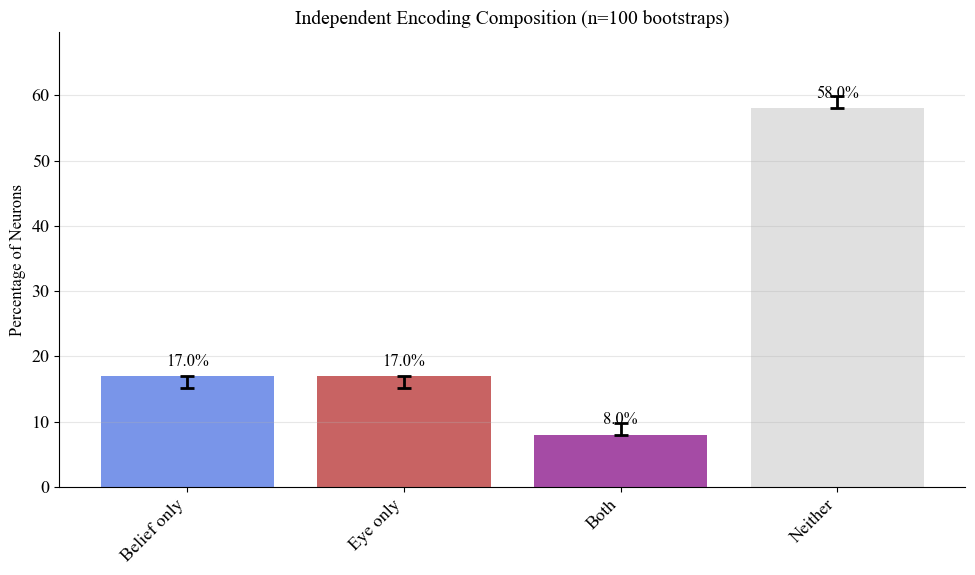


Quick Bootstrap Summary (95% CI):
Belief only: 17.0% (CI: 15.2% - 17.0%)
Eye only: 17.0% (CI: 15.2% - 17.0%)
Both: 8.0% (CI: 8.0% - 9.8%)
Neither: 58.0% (CI: 58.0% - 59.8%)


In [49]:
def quick_bootstrap_quadrant_analysis(timedf, n_bootstrap=100):  # Reduced from 1000
    """
    Quick bootstrap analysis on quadrant composition - reduced iterations for testing.
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural data by time point
    n_bootstrap : int
        Number of bootstrap iterations (reduced for speed)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import LinearRegression
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy()
    n_neurons = neural_data.shape[1]
    
    # First calculate original categorization
    print("Calculating original categorization...")
    
    # Reshape data for sklearn
    belief_2d = belief_data.reshape(-1, 1)
    eye_2d = eye_data.reshape(-1, 1)
    
    # Calculate independent belief coefficients
    model_eye = LinearRegression()
    model_eye.fit(eye_2d, neural_data)
    neural_residuals_after_eye = neural_data - model_eye.predict(eye_2d)
    
    model_indep_belief = LinearRegression()
    model_indep_belief.fit(neural_residuals_after_eye, belief_2d)
    indep_belief_coefs = model_indep_belief.coef_[0]
    
    # Calculate independent eye coefficients
    model_belief = LinearRegression()
    model_belief.fit(belief_2d, neural_data)
    neural_residuals_after_belief = neural_data - model_belief.predict(belief_2d)
    
    model_indep_eye = LinearRegression()
    model_indep_eye.fit(neural_residuals_after_belief, eye_2d)
    indep_eye_coefs = model_indep_eye.coef_[0]
    
    # Calculate thresholds
    indep_belief_abs = np.abs(indep_belief_coefs)
    indep_eye_abs = np.abs(indep_eye_coefs)
    threshold_indep_belief = np.percentile(indep_belief_abs, 75)
    threshold_indep_eye = np.percentile(indep_eye_abs, 75)
    
    # Categorize neurons
    belief_mask = (indep_belief_abs >= threshold_indep_belief) & (indep_eye_abs < threshold_indep_eye)
    eye_mask = (indep_belief_abs < threshold_indep_belief) & (indep_eye_abs >= threshold_indep_eye)
    both_mask = (indep_belief_abs >= threshold_indep_belief) & (indep_eye_abs >= threshold_indep_eye)
    neither_mask = ~(belief_mask | eye_mask | both_mask)
    
    # Original proportions
    original_counts = np.array([
        np.sum(belief_mask),  # Belief only
        np.sum(eye_mask),     # Eye only
        np.sum(both_mask),    # Both
        np.sum(neither_mask)  # Neither
    ])
    original_proportions = original_counts / n_neurons
    
    # Print original proportions
    quadrant_names = ['Belief only', 'Eye only', 'Both', 'Neither']
    print("\nOriginal proportions:")
    for i, name in enumerate(quadrant_names):
        print(f"  {name}: {original_proportions[i]*100:.1f}%")
    
    # Quick bootstrap with fewer iterations
    print(f"\nPerforming {n_bootstrap} quick bootstrap iterations...")
    bootstrap_proportions = np.zeros((n_bootstrap, 4))
    
    n_trials = len(belief_data)
    
    for i in range(n_bootstrap):
        if i % 1 == 0:  # Progress update
            print(f"  Iteration {i}/{n_bootstrap}")
        
        # Resample trials
        resample_idx = np.random.choice(n_trials, size=n_trials, replace=True)
        
        # Resample data
        neural_resample = neural_data[resample_idx]
        belief_resample = belief_2d[resample_idx]
        eye_resample = eye_2d[resample_idx]
        
        # Calculate coefficients for resampled data
        model_eye.fit(eye_resample, neural_resample)
        neural_residuals_after_eye = neural_resample - model_eye.predict(eye_resample)
        model_indep_belief.fit(neural_residuals_after_eye, belief_resample)
        indep_belief_coefs = model_indep_belief.coef_[0]
        
        model_belief.fit(belief_resample, neural_resample)
        neural_residuals_after_belief = neural_resample - model_belief.predict(belief_resample)
        model_indep_eye.fit(neural_residuals_after_belief, eye_resample)
        indep_eye_coefs = model_indep_eye.coef_[0]
        
        # Calculate thresholds and categorize
        indep_belief_abs = np.abs(indep_belief_coefs)
        indep_eye_abs = np.abs(indep_eye_coefs)
        threshold_indep_belief = np.percentile(indep_belief_abs, 75)
        threshold_indep_eye = np.percentile(indep_eye_abs, 75)
        
        belief_mask = (indep_belief_abs >= threshold_indep_belief) & (indep_eye_abs < threshold_indep_eye)
        eye_mask = (indep_belief_abs < threshold_indep_belief) & (indep_eye_abs >= threshold_indep_eye)
        both_mask = (indep_belief_abs >= threshold_indep_belief) & (indep_eye_abs >= threshold_indep_eye)
        
        # Count directly
        bootstrap_proportions[i, 0] = np.sum(belief_mask) / n_neurons  # Belief only
        bootstrap_proportions[i, 1] = np.sum(eye_mask) / n_neurons     # Eye only
        bootstrap_proportions[i, 2] = np.sum(both_mask) / n_neurons    # Both
        bootstrap_proportions[i, 3] = 1 - np.sum(bootstrap_proportions[i, :3])  # Neither
    
    # Calculate 95% confidence intervals
    ci_lower = np.percentile(bootstrap_proportions, 2.5, axis=0) * 100
    ci_upper = np.percentile(bootstrap_proportions, 97.5, axis=0) * 100
    proportions = original_proportions * 100
    
    # Create simple bar plot with CI
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['royalblue', 'firebrick', 'purple', 'lightgray']
    x_pos = np.arange(len(quadrant_names))
    
    bars = ax.bar(x_pos, proportions, color=colors, alpha=0.7)
    
    # Add error bars
    for i in range(len(quadrant_names)):
        err_lower = proportions[i] - ci_lower[i]
        err_upper = ci_upper[i] - proportions[i]
        ax.errorbar(x_pos[i], proportions[i], yerr=[[err_lower], [err_upper]], 
                   fmt='none', color='black', capsize=5, capthick=2)
    
    # Add percentage labels
    for i, prop in enumerate(proportions):
        ax.text(x_pos[i], prop + 1, f'{prop:.1f}%', ha='center', va='bottom', fontsize=12)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(quadrant_names, rotation=45, ha='right')
    ax.set_ylabel('Percentage of Neurons', fontsize=12)
    ax.set_title(f'Independent Encoding Composition (n={n_bootstrap} bootstraps)', fontsize=14)
    ax.set_ylim(0, max(proportions) * 1.2)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('quick_bootstrap_quadrant_composition.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\nQuick Bootstrap Summary (95% CI):")
    for i, name in enumerate(quadrant_names):
        print(f"{name}: {proportions[i]:.1f}% (CI: {ci_lower[i]:.1f}% - {ci_upper[i]:.1f}%)")
    
    return proportions, ci_lower, ci_upper

# Run the quick bootstrap
proportions, ci_lower, ci_upper = quick_bootstrap_quadrant_analysis(timedf)

Calculating coefficients for each neuron...

Paired Wilcoxon test:
Statistic: 2840.0
P-value: 3.4690e-01


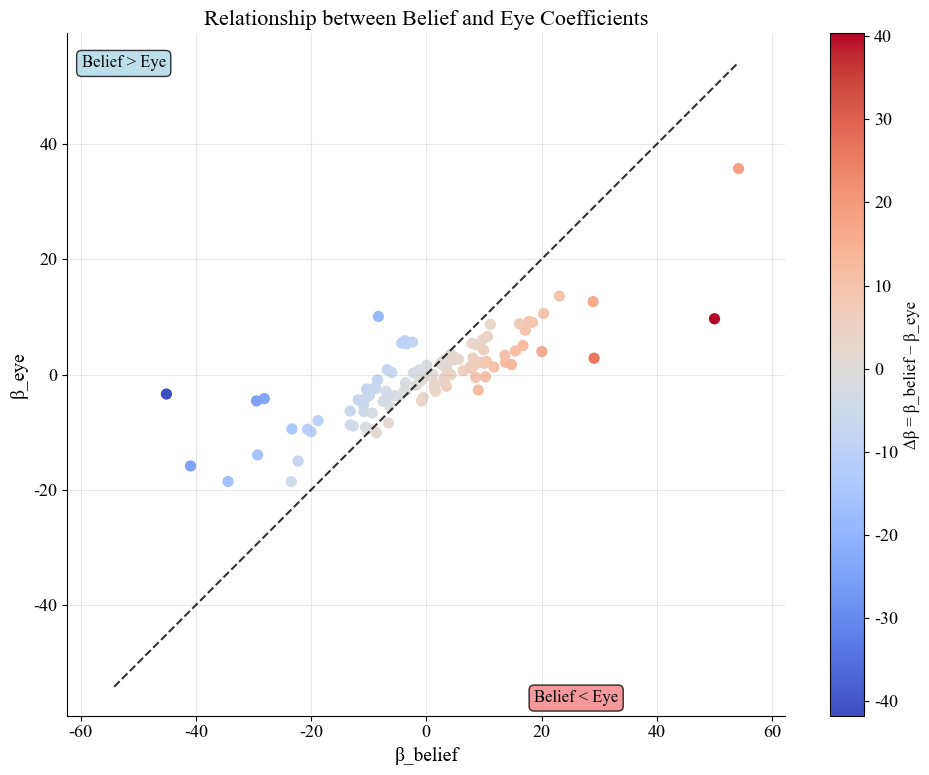

In [54]:
def violin_coefficient_difference(timedf):
    """
    Create violin plot of Δβ = β_belief – β_eye with paired Wilcoxon test.
    Shows relative strength of belief vs eye components in neural responses.
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural data
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import LinearRegression
    from scipy.stats import wilcoxon
    import seaborn as sns
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy()
    n_neurons = neural_data.shape[1]
    
    # Reshape data for sklearn
    belief_2d = belief_data.reshape(-1, 1)
    eye_2d = eye_data.reshape(-1, 1)
    
    print("Calculating coefficients for each neuron...")
    
    # Calculate total belief coefficients (β_belief)
    model_total_belief = LinearRegression()
    model_total_belief.fit(neural_data, belief_2d)
    beta_belief = model_total_belief.coef_[0]
    
    # Calculate total eye coefficients (β_eye)
    model_total_eye = LinearRegression()
    model_total_eye.fit(neural_data, eye_2d)
    beta_eye = model_total_eye.coef_[0]
    
    # Calculate the difference Δβ = β_belief – β_eye
    delta_beta = beta_belief - beta_eye
    
    # Perform paired Wilcoxon test
    stat, p_value = wilcoxon(beta_belief, beta_eye)
    
    print(f"\nPaired Wilcoxon test:")
    print(f"Statistic: {stat}")
    print(f"P-value: {p_value:.4e}")
    

    # Create a scatter plot to show the relationship
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Scatter plot of belief vs eye coefficients
    scatter = ax.scatter(beta_belief, beta_eye, alpha=0.99, c=delta_beta, 
                        cmap='coolwarm', s=50)
    
    # Add colorbar for delta beta
    cbar = plt.colorbar(scatter)
    cbar.set_label('Δβ = β_belief – β_eye', fontsize=12)
    
    # Add diagonal line (β_belief = β_eye)
    max_val = max(np.max(np.abs(beta_belief)), np.max(np.abs(beta_eye)))
    ax.plot([-max_val, max_val], [-max_val, max_val], 'k--', alpha=0.8, linewidth=1.5)
    
    # Add text for quadrants
    ax.text(0.02, 0.95, 'Belief > Eye', transform=ax.transAxes, 
            fontsize=12, bbox=dict(boxstyle="round", facecolor='lightblue', alpha=0.8))
    ax.text(0.65, 0.02, 'Belief < Eye', transform=ax.transAxes, 
            fontsize=12, bbox=dict(boxstyle="round", facecolor='lightcoral', alpha=0.8))
    
    ax.set_xlabel('β_belief', fontsize=14)
    ax.set_ylabel('β_eye', fontsize=14)
    ax.set_title('Relationship between Belief and Eye Coefficients', fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    
    plt.tight_layout()
    plt.savefig('belief_vs_eye_coefficients_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    


# Run the analysis
results = violin_coefficient_difference(timedf)

Using fixed dt = 6.0 ms
Testing 26 lags (0 – 150 ms)…


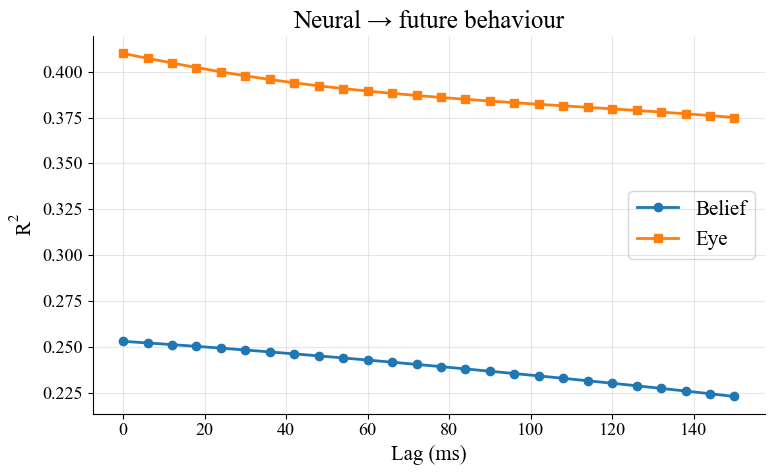


Summary
  best lag belief :   0 ms  (R² = 0.253)
  best lag eye    :   0 ms  (R² = 0.410)
  difference      :   0 ms


In [12]:
def temporal_prediction_analysis(
        timedf,
        dt=0.006,                 # seconds per sample  ➜ 6 ms
        max_lag_ms=150,
        step_ms=6):
    """
    Analyze how well neural activity predicts future belief/eye movements
    at different time lags.

    Parameters
    ----------
    timedf : pandas.DataFrame
        Must contain columns 'PPC', 'belief', 'eye', 'timer'.
        * 'PPC'   : iterable of shape (n_neurons,) per row
        * 'belief': scalar or 1‑element array per row
        * 'eye'   : scalar or 1‑element array per row
        * 'timer' : 1, 2, 3 … counting samples from trial start
    dt : float, default 0.006
        Length of one sample in **seconds** (6 ms for your data).
    max_lag_ms : int, default 150
        Maximum time lag to test (milliseconds).
    step_ms : int, default 6
        Step size between tested lags (milliseconds).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score

    # ----------  unpack data ----------
    neural_data = np.vstack(timedf["PPC"].to_numpy())           # (T, n_neurons)
    belief_data = np.asarray(timedf["belief"]).ravel()          # ensure 1‑D
    eye_data    = np.asarray(timedf["eye"]).ravel()
    timer_data  = np.asarray(timedf["timer"])                   # 1, 2, 3 …

    # ----------  constant step size ----------
    dt_ms = dt * 1_000                                          # 6 ms
    print(f"Using fixed dt = {dt_ms:.1f} ms")

    # ----------  lags in *steps* ----------
    time_lags_ms    = np.arange(0, max_lag_ms + step_ms, step_ms)
    time_lags_steps = (time_lags_ms / dt_ms).astype(int)        # exact because step_ms = dt_ms

    # ----------  containers ----------
    r2_belief, r2_eye = [], []
    print(f"Testing {len(time_lags_ms)} lags (0 – {max_lag_ms} ms)…")

    # ----------  iterate over lags ----------
    for lag_steps in time_lags_steps:
        if lag_steps == 0:
            X          = neural_data
            y_belief   = belief_data
            y_eye      = eye_data
        else:
            X          = neural_data[:-lag_steps]
            y_belief   = belief_data[lag_steps:]
            y_eye      = eye_data[lag_steps:]

        if len(X) < 10:                      # avoid tiny fits
            r2_belief.append(np.nan)
            r2_eye.append(np.nan)
            continue

        # belief
        mdl_belief     = LinearRegression().fit(X, y_belief)
        r2_belief.append(r2_score(y_belief, mdl_belief.predict(X)))

        # eye
        mdl_eye        = LinearRegression().fit(X, y_eye)
        r2_eye.append(r2_score(y_eye, mdl_eye.predict(X)))

    r2_belief, r2_eye = np.asarray(r2_belief), np.asarray(r2_eye)

    # ----------  plotting ----------
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(time_lags_ms, r2_belief, "o-", label="Belief")
    ax.plot(time_lags_ms, r2_eye,    "s-", label="Eye")
    ax.set(xlabel="Lag (ms)", ylabel=r"$R^2$", title="Neural → future behaviour")
    ax.grid(alpha=0.3);  ax.legend()
    plt.tight_layout();  plt.show()

    # ----------  summary ----------
    best_b_idx, best_e_idx   = np.nanargmax(r2_belief), np.nanargmax(r2_eye)
    best_b_ms,  best_e_ms    = time_lags_ms[best_b_idx],  time_lags_ms[best_e_idx]
    best_b_r2,  best_e_r2    = r2_belief[best_b_idx],     r2_eye[best_e_idx]

    print("\nSummary")
    print(f"  best lag belief : {best_b_ms:3d} ms  (R² = {best_b_r2:.3f})")
    print(f"  best lag eye    : {best_e_ms:3d} ms  (R² = {best_e_r2:.3f})")
    print(f"  difference      : {abs(best_b_ms - best_e_ms):3d} ms")

    return dict(time_lags_ms=time_lags_ms,
                r2_belief=r2_belief, r2_eye=r2_eye,
                optimal_lag_belief=best_b_ms, optimal_lag_eye=best_e_ms,
                optimal_r2_belief=best_b_r2, optimal_r2_eye=best_e_r2)

results = temporal_prediction_analysis(timedf)

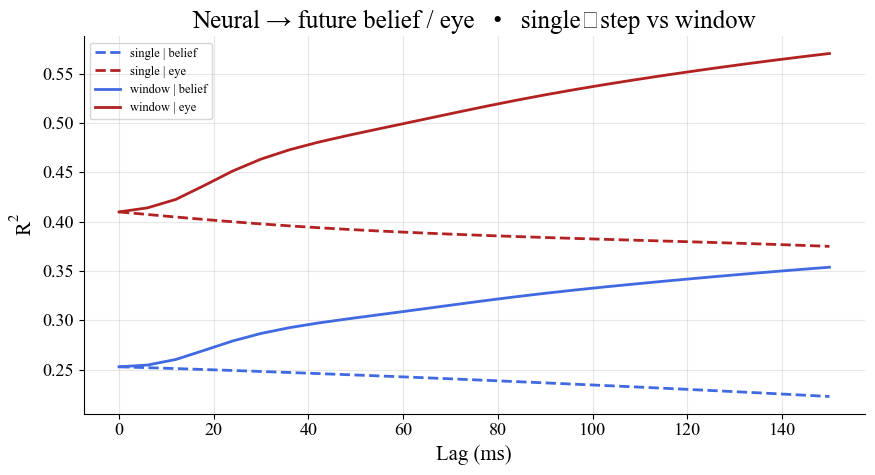


Best lags (ms) and R²
  single  belief:   0 ms (R²=0.253)   eye:   0 ms (R²=0.410)
  window  belief: 150 ms (R²=0.354)   eye: 150 ms (R²=0.570)


In [17]:
def temporal_prediction_analysis_both(
        timedf,
        dt      = 0.006,          # sec per sample  (6 ms)
        max_ms  = 150,            # max lag in ms
        step_ms = 6):             # lag resolution
    """
    Compare single‑step (t‑k) vs window (t‑k … t) neural predictors.
    """
    import numpy as np, matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics  import r2_score

    # ------------  unpack ------------
    X_all   = np.vstack(timedf["PPC"].to_numpy())   # (T, n_neurons)
    y_bel   = np.asarray(timedf["belief"]).ravel()
    y_eye   = np.asarray(timedf["eye"]).ravel()

    dt_ms   = dt * 1000
    lags_ms = np.arange(0, max_ms + step_ms, step_ms)
    lags_st = (lags_ms / dt_ms).astype(int)

    r2     = {m: np.full((len(lags_ms), 2), np.nan)   # cols: belief, eye
              for m in ("single", "window")}

    # ------------  iterate over lags ------------
    for i, k in enumerate(lags_st):
        if k == 0:
            # trivial: predictors and targets aligned
            X_s = X_all
            X_w = X_all
            y_b = y_bel
            y_e = y_eye
        else:
            T   = len(X_all) - k                      # usable length
            X_s = X_all[:-k]                          # single‑step @ t‑k
            # window   shape = (T, (k+1)*n_neurons)  (flattened)
            X_w = np.hstack([X_all[j : j+T] for j in range(k+1)])
            y_b = y_bel[k:]
            y_e = y_eye[k:]

        if len(X_s) < 10:                # not enough samples
            continue

        for name, X in (("single", X_s), ("window", X_w)):
            r2[name][i, 0] = r2_score(y_b, LinearRegression().fit(X, y_b).predict(X))
            r2[name][i, 1] = r2_score(y_e, LinearRegression().fit(X, y_e).predict(X))

    # ------------  plotting ------------
    fig, ax = plt.subplots(figsize=(9, 5))
    styles  = dict(single="--", window="-")
    colors  = dict(belief="royalblue", eye="firebrick")
    for mode in ("single", "window"):
        ax.plot(lags_ms, r2[mode][:, 0], styles[mode],
                label=f"{mode} | belief",  color=colors["belief"])
        ax.plot(lags_ms, r2[mode][:, 1], styles[mode],
                label=f"{mode} | eye",     color=colors["eye"])

    ax.set(xlabel="Lag (ms)", ylabel=r"$R^2$",
           title="Neural → future belief / eye   •   single‑step vs window")
    ax.grid(alpha=.3); ax.legend(fontsize=9); plt.tight_layout(); plt.show()

    # ------------  summary ------------
    def best(arr):            # helper
        idx = np.nanargmax(arr)
        return lags_ms[idx], arr[idx]

    print("\nBest lags (ms) and R²")
    for mode in ("single", "window"):
        b_ms, b_r2 = best(r2[mode][:, 0])
        e_ms, e_r2 = best(r2[mode][:, 1])
        print(f"  {mode:6s}  belief: {b_ms:3d} ms (R²={b_r2:.3f})   "
              f"eye: {e_ms:3d} ms (R²={e_r2:.3f})")

    return {"lags_ms": lags_ms,
            "r2_single_belief": r2["single"][:, 0],
            "r2_single_eye"   : r2["single"][:, 1],
            "r2_window_belief": r2["window"][:, 0],
            "r2_window_eye"   : r2["window"][:, 1]}

results = temporal_prediction_analysis_both(timedf)

In [18]:
notify()